Assignment 16 - SVM, Trees, Ensembles, Validation & Unsupervised Learning

Dataset

Dataset Name: Global Superstore Orders
Kaggle Link: https://www.kaggle.com/datasets/laibaanwer/superstore-sales-dataset

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [7]:
## Load Dataset
df = pd.read_csv("SuperStoreOrders.csv", encoding="unicode_escape")

df["sales"] = df["sales"].astype(str)
df["sales"] = df["sales"].str.replace(",", "", regex=False)
df["sales"] = pd.to_numeric(df["sales"])
df["high_sales"] = (df["sales"] > df["sales"].mean()).astype(int)
df.head()

,ï»¿order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,high_sales
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011,1
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011,0
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011,0
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011,0
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011,0


In [8]:
print("Shape :", df.shape)
print("\nColumns")
print(df.columns)
print("\nTarget Values")
print(df["high_sales"].value_counts())

Shape : (51290, 22)

Columns
Index(['ï»¿order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name',
       'segment', 'state', 'country', 'market', 'region', 'product_id',
       'category', 'sub_category', 'product_name', 'sales', 'quantity',
       'discount', 'profit', 'shipping_cost', 'order_priority', 'year',
       'high_sales'],
      dtype='object')

Target Values
high_sales
0    38235
1    13055
Name: count, dtype: int64


### Observation is a new target column named **high_sales** is created. Orders with sales greater than the average are labeled as 1, otherwise 0.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

features = df[["profit","quantity","discount","shipping_cost","category","segment","region"]]

target = df["high_sales"]

numeric_features = ["profit","quantity","discount","shipping_cost"]

categorical_features = ["category","segment","region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

x_train, x_test, y_train, y_test = train_test_split(features,target,test_size=0.2,random_state=42)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Task 1 - Support Vector Machine (SVM)
if 'df' not in globals():
    from pathlib import Path
    csv_path = Path.cwd() / 'SuperStoreOrders.csv'
    if not csv_path.exists():
        csv_path = Path('d:/GenAI-Asssignements-TuteDude/A16/SuperStoreOrders.csv')
    df = pd.read_csv(csv_path, encoding='unicode_escape')
    df['sales'] = df['sales'].astype(str)
    df['sales'] = df['sales'].str.replace(',', '', regex=False)
    df['sales'] = pd.to_numeric(df['sales'])
    df['high_sales'] = (df['sales'] > df['sales'].mean()).astype(int)

features = df[["profit", "quantity", "discount", "shipping_cost", "category", "segment", "region"]]
target = df["high_sales"]
numeric_features = ["profit", "quantity", "discount", "shipping_cost"]
categorical_features = ["category", "segment", "region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [12]:
## Linear Kernel
df = df.sample(n=5000, random_state=42)

linear_model = Pipeline([("preprocessor", preprocessor),("model", SVC(kernel="linear"))])

linear_model.fit(x_train, y_train)
linear_predictions = linear_model.predict(x_test)

linear_accuracy = accuracy_score(y_test,linear_predictions)
print("Linear Kernel Accuracy :", linear_accuracy)

## RBF Kernel
rbf_model = Pipeline([("preprocessor", preprocessor),("model", SVC(kernel="rbf"))])

rbf_model.fit(x_train, y_train)
rbf_predictions = rbf_model.predict(x_test)
rbf_accuracy = accuracy_score(y_test,rbf_predictions)
print("RBF Kernel Accuracy :", rbf_accuracy)

Linear Kernel Accuracy : 0.9102164164554494
RBF Kernel Accuracy : 0.9269838175082862


In [14]:
print("Linear Kernel :", linear_accuracy)
print("RBF Kernel :", rbf_accuracy)

if linear_accuracy > rbf_accuracy:
    print("\nLinear Kernel performed better.")
elif rbf_accuracy > linear_accuracy:
    print("\nRBF Kernel performed better.")
else:
    print("\nBoth kernels performed equally.")

Linear Kernel : 0.9102164164554494
RBF Kernel : 0.9269838175082862

RBF Kernel performed better.


### Observation from both Linear and RBF kernels were trained using the same dataset. Their accuracies were compared to understand how different kernels affect the performance of an SVM classifier.

# Task 2 - Decision Tree Algorithm

In this task, a Decision Tree Classifier is trained. The tree is visualized, and two models are compared to understand underfitting and overfitting.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

decision_tree = Pipeline(
    [("preprocessor", preprocessor),("model", DecisionTreeClassifier(random_state=42,max_depth=3))])

decision_tree.fit(x_train, y_train)
tree_predictions = decision_tree.predict(x_test)

tree_accuracy = accuracy_score(y_test,tree_predictions)
print("Decision Tree Accuracy :", tree_accuracy)

Decision Tree Accuracy : 0.9126535387015012


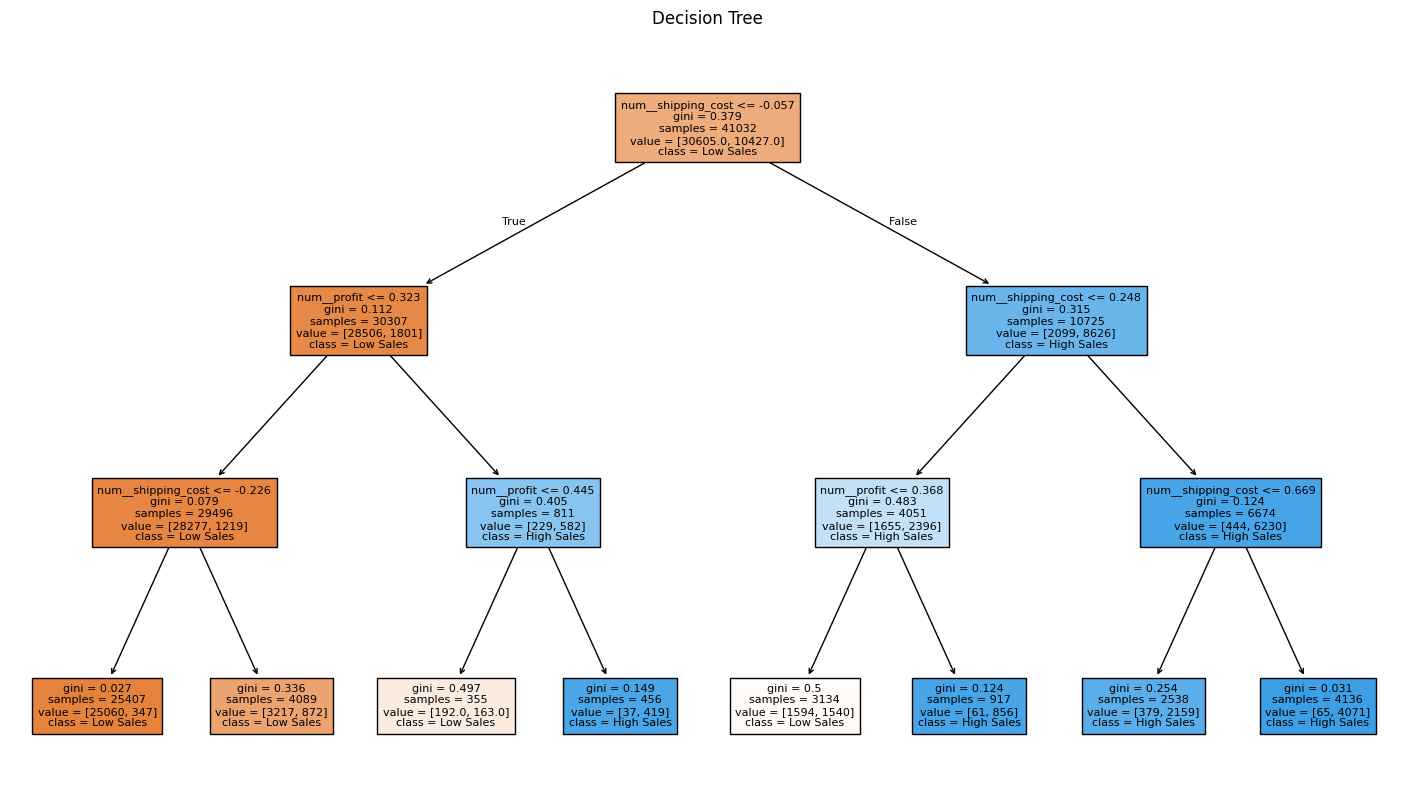

In [16]:
## Decision Tree Visualization
x_train_encoded = preprocessor.fit_transform(x_train)
feature_names = preprocessor.get_feature_names_out()
tree_model = DecisionTreeClassifier(max_depth=3,random_state=42)
tree_model.fit(x_train_encoded, y_train)

plt.figure(figsize=(18,10))
plot_tree(tree_model,feature_names=feature_names,class_names=["Low Sales","High Sales"],filled=True,fontsize=8)
plt.title("Decision Tree")
plt.show()

### Observation is that the tree visualization shows how the model makes decisions using different features. The maximum depth is limited to keep the tree simple and easy to understand.

In [17]:
## Underfitting Model
underfit_model = Pipeline([("preprocessor", preprocessor),("model", DecisionTreeClassifier(max_depth=2,random_state=42))])
underfit_model.fit(x_train, y_train)

train_prediction = underfit_model.predict(x_train)
test_prediction = underfit_model.predict(x_test)

train_accuracy = accuracy_score(y_train,train_prediction)
test_accuracy = accuracy_score(y_test,test_prediction)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy : 0.9135552739325404
Testing Accuracy : 0.916162994735816


In [18]:
## Overfitting Model
overfit_model = Pipeline([("preprocessor", preprocessor),("model", DecisionTreeClassifier(random_state=42))])
overfit_model.fit(x_train, y_train)

train_prediction = overfit_model.predict(x_train)
test_prediction = overfit_model.predict(x_test)

train_accuracy = accuracy_score(y_train,train_prediction)
test_accuracy = accuracy_score(y_test,test_prediction)

print("Training Accuracy :", train_accuracy)
print("Testing Accuracy :", test_accuracy)

Training Accuracy : 1.0
Testing Accuracy : 0.90836420354845


### Observation

- A shallow tree (low max_depth) is simple and may underfit the data.
- A deep tree (high max_depth) learns the training data very well but may not perform equally well on unseen data.
- Comparing training and testing accuracy helps identify underfitting and overfitting.

# Task 3 - Train vs Validation vs Test Split

The dataset is divided into training, validation and testing sets. A simple parameter (max_depth) is tuned using the validation set and the best model is evaluated on the test set.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

if 'df' not in globals():
    from pathlib import Path
    csv_path = Path.cwd() / 'SuperStoreOrders.csv'
    if not csv_path.exists():
        csv_path = Path('d:/GenAI-Asssignements-TuteDude/A16/SuperStoreOrders.csv')
    df = pd.read_csv(csv_path, encoding='unicode_escape')
    df['sales'] = df['sales'].astype(str)
    df['sales'] = df['sales'].str.replace(',', '', regex=False)
    df['sales'] = pd.to_numeric(df['sales'])
    df['high_sales'] = (df['sales'] > df['sales'].mean()).astype(int)

if 'preprocessor' not in globals():
    features = df[["profit", "quantity", "discount", "shipping_cost", "category", "segment", "region"]]
    target = df["high_sales"]
    numeric_features = ["profit", "quantity", "discount", "shipping_cost"]
    categorical_features = ["category", "segment", "region"]
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", numeric_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

# First split into train and test
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Split training data into train and validation
x_train_final, x_validation, y_train_final, y_validation = train_test_split(x_train, y_train, test_size=0.25, random_state=42)

depth_values = [2, 3, 5, 7]

best_depth = 2
best_accuracy = 0

for depth in depth_values:
    model = Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", DecisionTreeClassifier(max_depth=depth, random_state=42))
        ]
    )

    model.fit(x_train_final, y_train_final)
    prediction = model.predict(x_validation)
    accuracy = accuracy_score(y_validation, prediction)
    print("Max Depth :", depth)
    print("Validation Accuracy :", accuracy)
    print()

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_depth = depth

print("Best Max Depth :", best_depth)

Max Depth : 2
Validation Accuracy : 0.9166504191850263

Max Depth : 3
Validation Accuracy : 0.9166504191850263

Max Depth : 5
Validation Accuracy : 0.9204523298888673

Max Depth : 7
Validation Accuracy : 0.9251316046012868

Best Max Depth : 7


In [20]:
final_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=best_depth,
            random_state=42
        ))
    ]
)

final_model.fit(x_train, y_train)
final_prediction = final_model.predict(x_test)
test_accuracy = accuracy_score(y_test,final_prediction)

print("Final Test Accuracy :", test_accuracy)


Final Test Accuracy : 0.9247416650419185


### Observation

Different values of max_depth were tested using the validation set. The depth with the highest validation accuracy was selected and evaluated on the test set.

In [21]:
# Task 4 - Cross Validation

cross_validation_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=best_depth,
            random_state=42
        ))
    ]
)

scores = cross_val_score(cross_validation_model,features,target,cv=5,scoring="accuracy")
print("Cross Validation Scores")
print(scores)
print()
print("Average Accuracy :", scores.mean())
print("Train-Test Accuracy :", test_accuracy)

Cross Validation Scores
[0.92425424 0.92737376 0.92571651 0.92415676 0.92308442]

Average Accuracy : 0.9249171378436343
Train-Test Accuracy : 0.9247416650419185


### Observation

Cross Validation trains and tests the model on multiple data splits. The average accuracy provides a more reliable estimate of model performance compared to a single train-test split.

In [22]:
# Task 5 - Bagging vs Boosting
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

bagging_model = Pipeline([("preprocessor", preprocessor),("model", BaggingClassifier(n_estimators=50,random_state=42))])

bagging_model.fit(x_train, y_train)
bagging_prediction = bagging_model.predict(x_test)
bagging_accuracy = accuracy_score(y_test,bagging_prediction)

print("Bagging Accuracy :", bagging_accuracy)


boosting_model = Pipeline([("preprocessor", preprocessor),("model", AdaBoostClassifier(n_estimators=50,random_state=42))])
boosting_model.fit(x_train, y_train)
boosting_prediction = boosting_model.predict(x_test)
boosting_accuracy = accuracy_score(y_test,boosting_prediction)
print("Boosting Accuracy :", boosting_accuracy)

Bagging Accuracy : 0.9296159095340222
Boosting Accuracy : 0.9216221485669721


### Observation

Bagging combines predictions from multiple models, while Boosting improves performance by learning from previous mistakes. Their accuracies can be compared to understand their effectiveness.

In [23]:
# Task 6 - Random Forest (Bagging)
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([("preprocessor", preprocessor),("model", RandomForestClassifier(n_estimators=100,random_state=42))])

random_forest.fit(x_train, y_train)
random_prediction = random_forest.predict(x_test)
random_accuracy = accuracy_score(y_test,random_prediction)
print("Decision Tree Accuracy :", tree_accuracy)
print("Bagging Accuracy :", bagging_accuracy)
print("Random Forest Accuracy :", random_accuracy)

Decision Tree Accuracy : 0.9126535387015012
Bagging Accuracy : 0.9296159095340222
Random Forest Accuracy : 0.9277636966270228


In [24]:
encoded_train = preprocessor.fit_transform(x_train)
feature_names = preprocessor.get_feature_names_out()
forest_model = RandomForestClassifier(n_estimators=100,random_state=42)

forest_model.fit(encoded_train, y_train)
importance = forest_model.feature_importances_

feature_importance = pd.DataFrame({"Feature": feature_names,"Importance": importance})

feature_importance = feature_importance.sort_values(by="Importance",ascending=False)
print(feature_importance.head(10))

                          Feature  Importance
3              num__shipping_cost    0.446038
0                     num__profit    0.302841
5   cat__category_Office Supplies    0.069039
1                   num__quantity    0.057546
2                   num__discount    0.032153
6        cat__category_Technology    0.021617
4         cat__category_Furniture    0.017699
7           cat__segment_Consumer    0.005718
8          cat__segment_Corporate    0.005307
13            cat__region_Central    0.004657


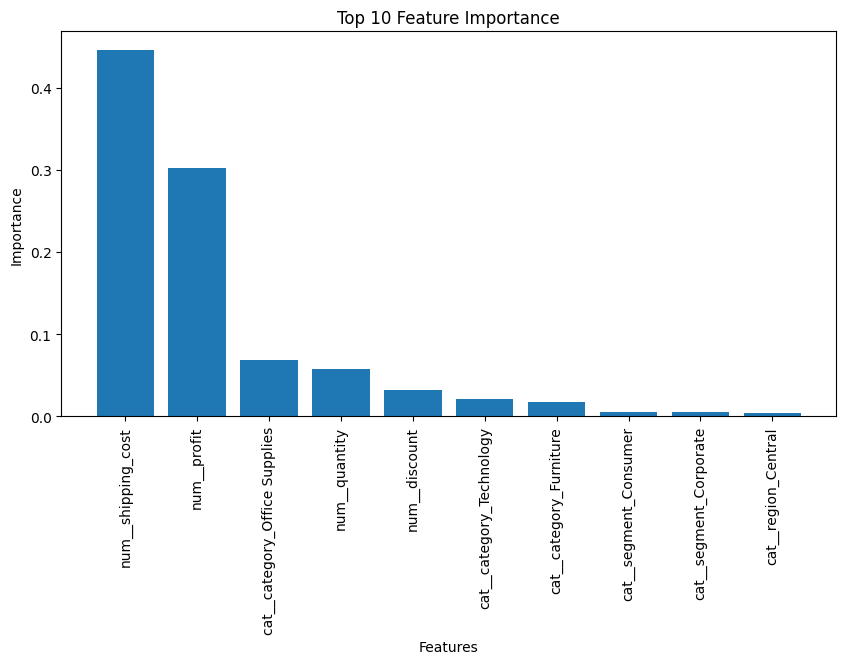

In [25]:
plt.figure(figsize=(10,5))
plt.bar(feature_importance["Feature"][:10],feature_importance["Importance"][:10])
plt.xticks(rotation=90)
plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

### Observation

Random Forest calculates the importance of each feature based on how useful it is for making predictions. Features with higher importance contribute more to the model.

# Conclusion

In this assignment, I learned how different supervised learning algorithms work, including SVM, Decision Tree, Bagging, Boosting and Random Forest. I also understood the importance of validation techniques like train-validation-test split and cross-validation. Finally, I learned how ensemble methods improve model performance and how feature importance helps identify the most influential features.